# 05 — WM-811K class-imbalance experiment

Analyze the complete task-05 experiment generated by `examples/run_imbalance_experiment.py`. Five isolated interventions were screened with seed 86; the unweighted baseline and the two best candidates were confirmed over seeds 86, 87, and 88. All model selection uses the persisted validation split. The frozen test split is not loaded or inspected.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
OUTPUT_DIRECTORY = PROJECT_ROOT / "output" / "class_imbalance"

run_summary = pd.read_csv(OUTPUT_DIRECTORY / "run_summary.csv")
strategy_summary = pd.read_csv(OUTPUT_DIRECTORY / "strategy_summary.csv")
per_class = pd.read_csv(OUTPUT_DIRECTORY / "per_class_results.csv")
class_weights = pd.read_csv(OUTPUT_DIRECTORY / "class_weights.csv")
metadata = json.loads(
    (OUTPUT_DIRECTORY / "experiment_metadata.json").read_text(encoding="utf-8")
)
selected_metrics = json.loads(
    (OUTPUT_DIRECTORY / "selected_validation" / "metrics.json").read_text(
        encoding="utf-8"
    )
)

assert metadata["test_set_used"] is False
assert metadata["selection_split"] == "validation"
assert metadata["train_samples"] == 121_063
assert metadata["validation_samples"] == 34_591
assert set(run_summary["seed"]) == {86, 87, 88}
print(f"Selected strategy: {metadata['selected_strategy']}")
print(f"Representative seed: {metadata['representative_seed']}")
print("Frozen test set used: no")

Selected strategy: inverse_sqrt_sampler
Representative seed: 88
Frozen test set used: no


## Imbalance and intervention strength

The selected sampler assigns each training observation a weight equal to the inverse square root of its class frequency. An epoch still contains 121,063 draws, with replacement. This moderates the long tail instead of forcing equal class probabilities.

,class_name,train_count,class_weight,expected_sampling_share,expected_epoch_samples,natural_share
27,Center,3006,0.558308,0.084058,10176.3,0.024830
28,Donut,389,1.552005,0.030239,3660.8,0.003213
29,Edge-Loc,3632,0.507920,0.092397,11185.9,0.030001
30,Edge-Ring,6776,0.371862,0.126204,15278.6,0.055971
31,Loc,2516,0.610257,0.076903,9310.1,0.020783
32,Near-full,104,3.001590,0.015635,1892.8,0.000859
33,Random,606,1.243459,0.037742,4569.1,0.005006
34,Scratch,835,1.059314,0.044303,5363.4,0.006897
35,none,103199,0.095286,0.492520,59625.9,0.852440


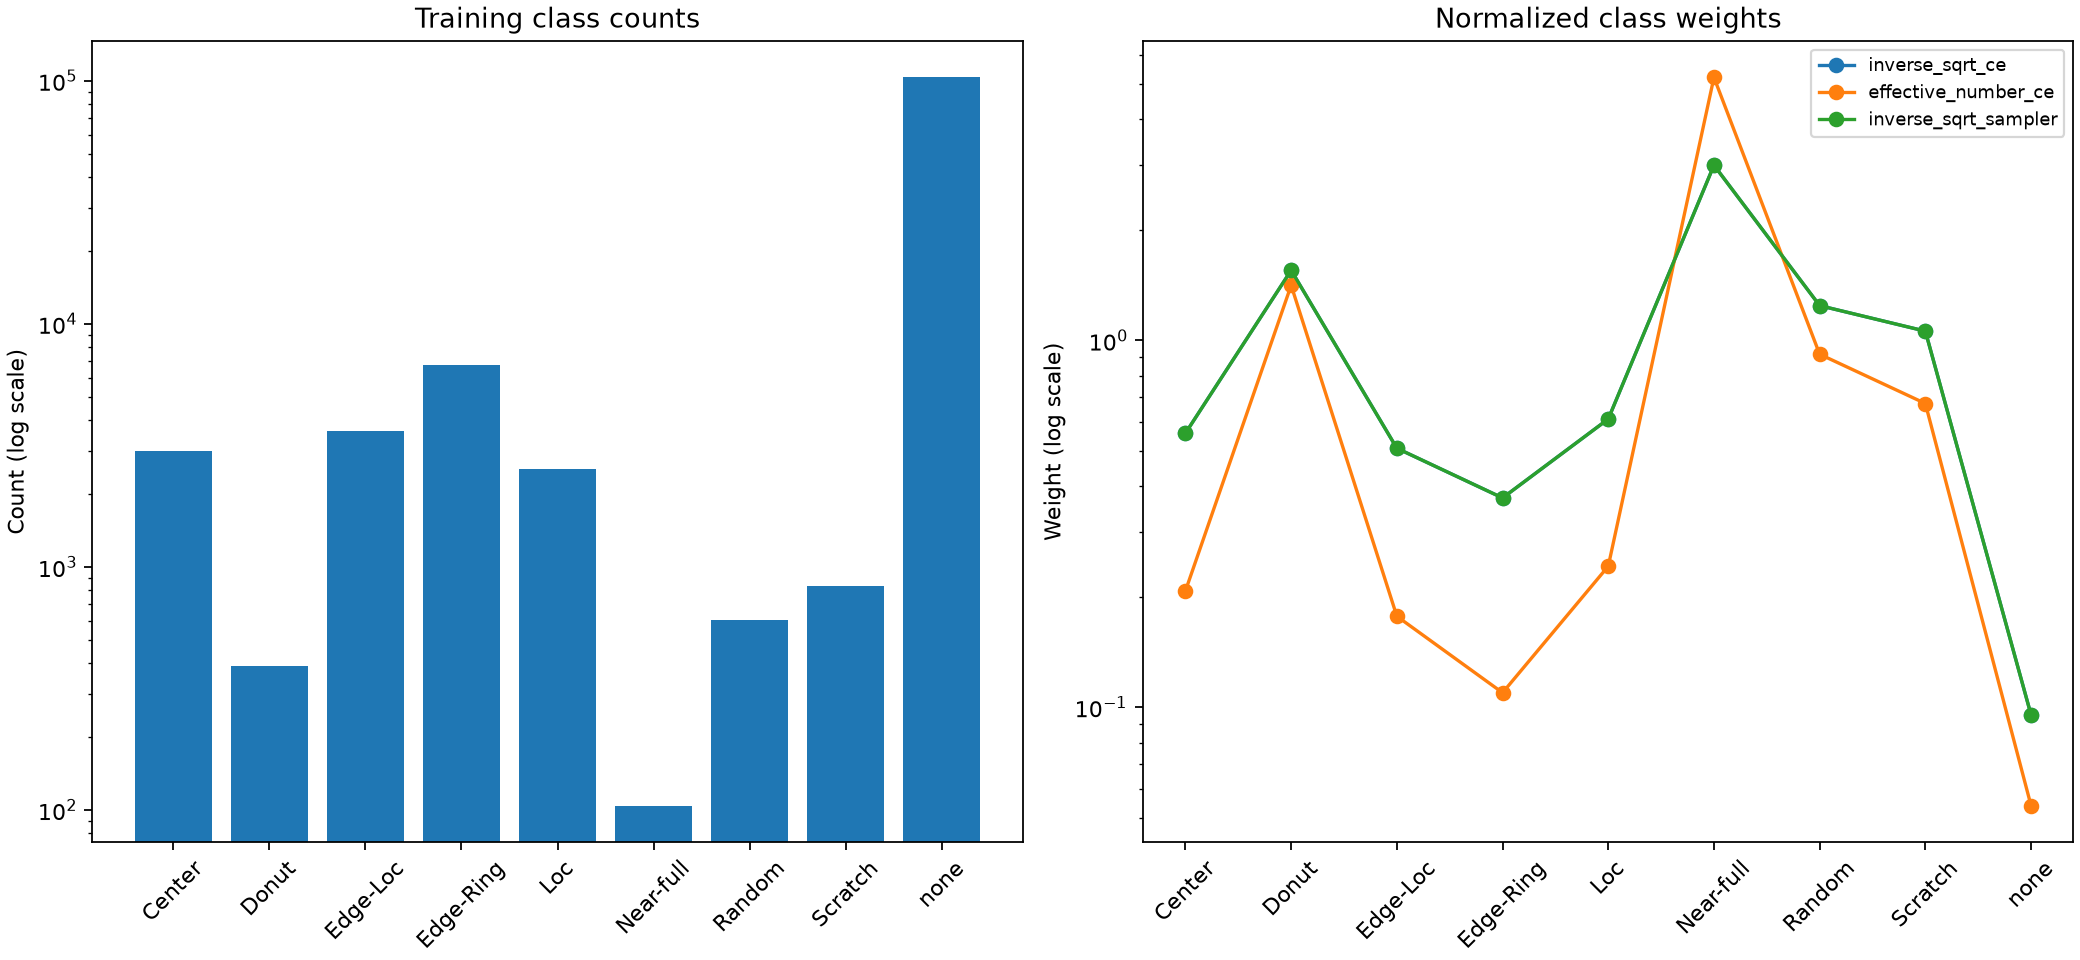

In [2]:
selected_weight_rows = class_weights.loc[
    class_weights["strategy"] == metadata["selected_strategy"],
    [
        "class_name",
        "train_count",
        "class_weight",
        "expected_sampling_share",
        "expected_epoch_samples",
    ],
].copy()
selected_weight_rows["natural_share"] = (
    selected_weight_rows["train_count"] / selected_weight_rows["train_count"].sum()
)
selected_weight_rows["expected_epoch_samples"] = selected_weight_rows[
    "expected_epoch_samples"
].round(1)
display(selected_weight_rows)
display(Image(filename=OUTPUT_DIRECTORY / "class_distribution_and_weights.png"))

## Screening and multi-seed confirmation

All candidates use the same 156,937-parameter CNN, optimization budget, preprocessing, and natural validation distribution. Only the loss or training sampler changes. The top two non-baseline candidates from seed 86 are compared with the unweighted baseline on two additional seeds.

,strategy,best_epoch,macro_f1,balanced_accuracy,accuracy,weighted_f1
3,inverse_sqrt_sampler,3,0.7888,0.8196,0.9526,0.9555
1,inverse_sqrt_ce,4,0.7730,0.7896,0.9631,0.9619
2,effective_number_ce,4,0.7681,0.8123,0.9570,0.9578
0,unweighted_ce,3,0.7445,0.7400,0.9594,0.9565
4,focal_loss,4,0.7194,0.6925,0.9583,0.9515


,strategy,runs,macro_f1_mean,macro_f1_std,balanced_accuracy_mean,balanced_accuracy_std,accuracy_mean,weighted_f1_mean
0,inverse_sqrt_sampler,3,0.7955,0.0066,0.8106,0.0159,0.9577,0.9588
1,inverse_sqrt_ce,3,0.7718,0.0127,0.7854,0.0136,0.9600,0.9586
2,unweighted_ce,3,0.7286,0.0138,0.7087,0.0299,0.9590,0.9544


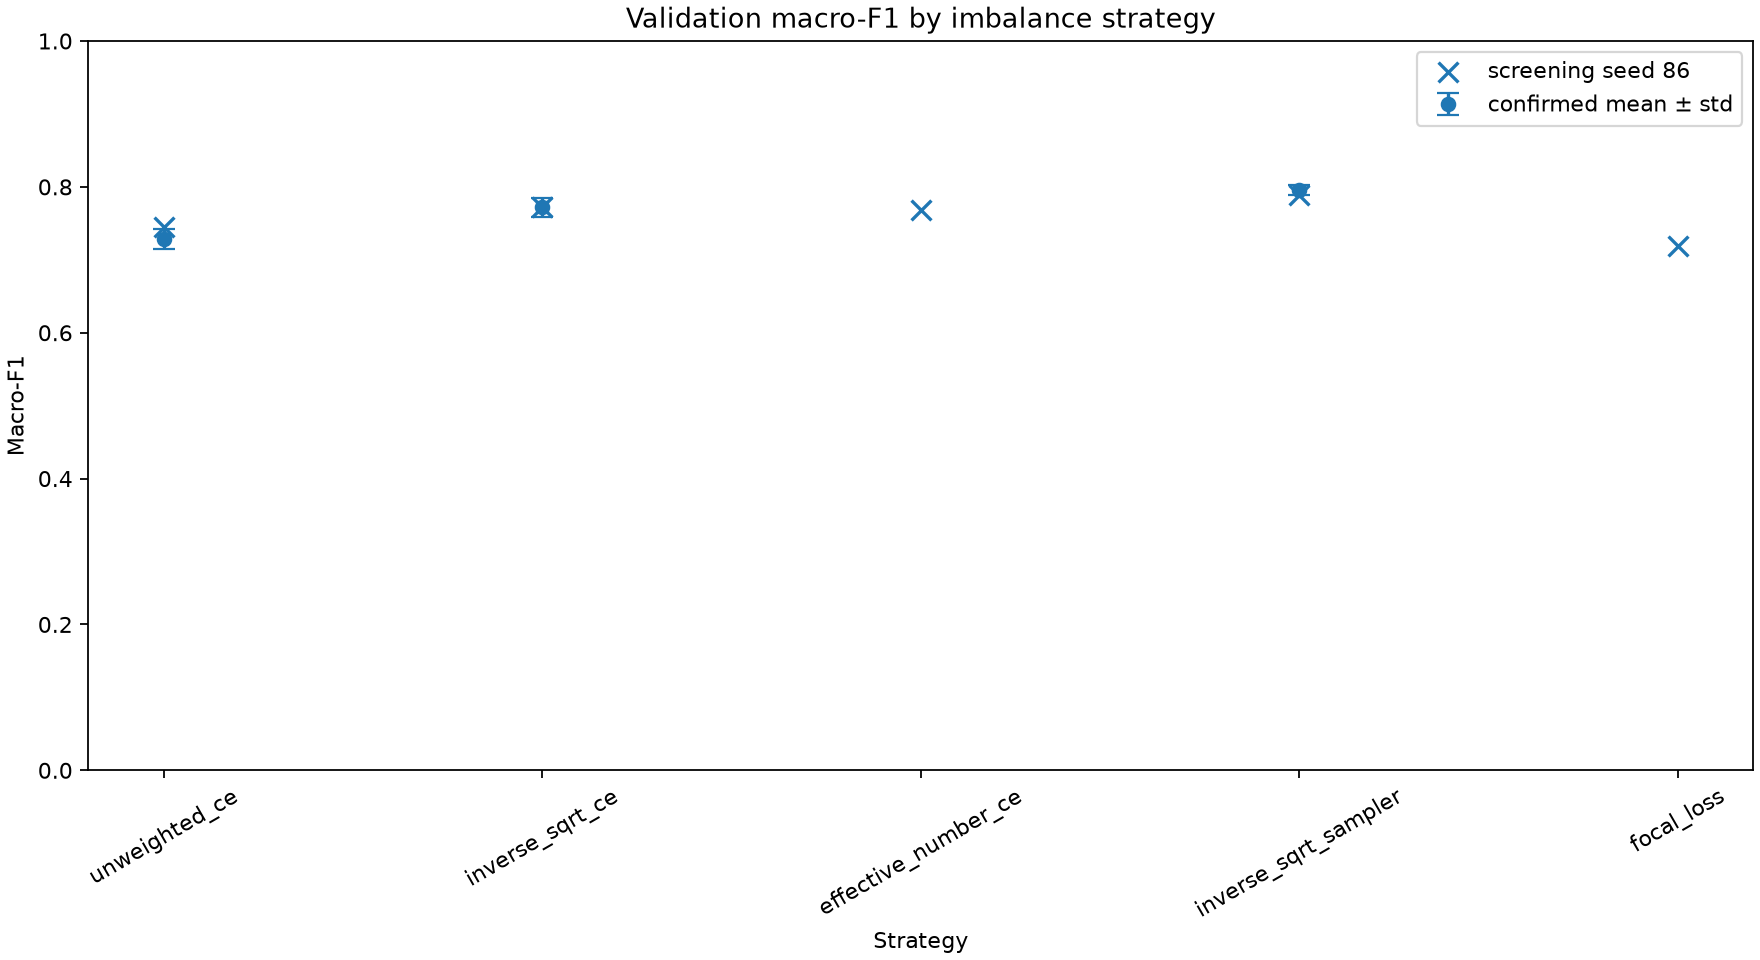

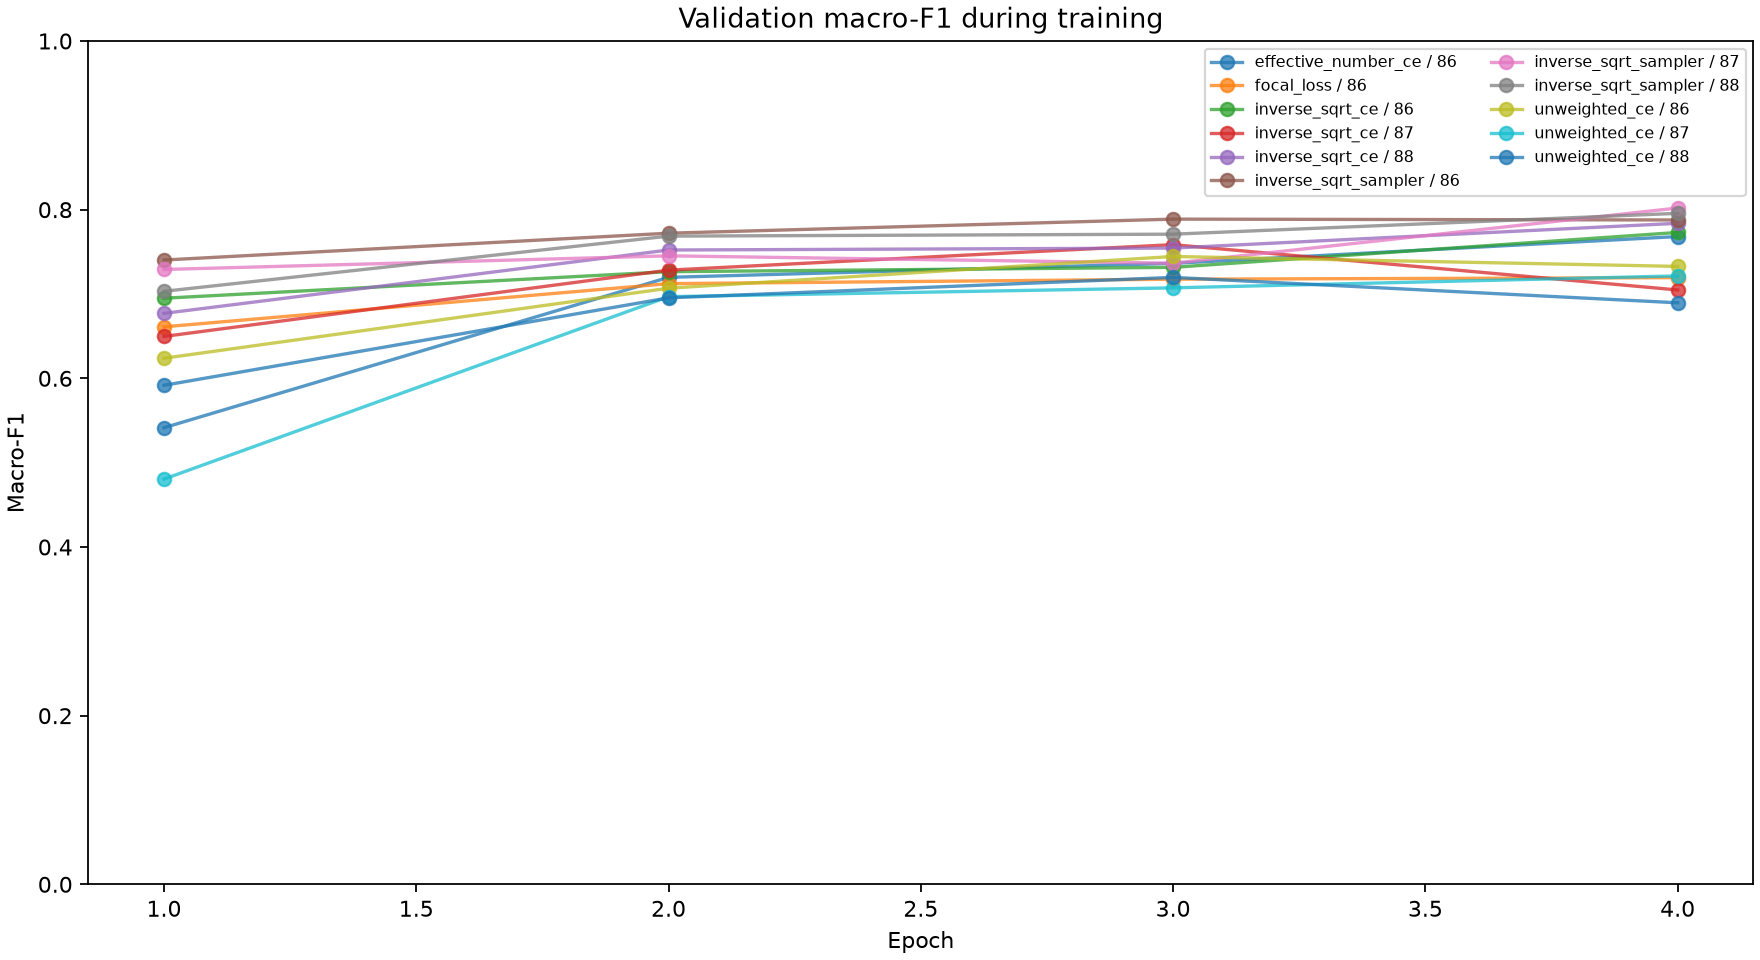

In [3]:
screening = run_summary.loc[
    run_summary["phase"] == "screening",
    [
        "strategy",
        "best_epoch",
        "macro_f1",
        "balanced_accuracy",
        "accuracy",
        "weighted_f1",
    ],
].sort_values("macro_f1", ascending=False)
display(screening.round(4))
display(strategy_summary.round(4))
display(Image(filename=OUTPUT_DIRECTORY / "strategy_comparison.png"))
display(Image(filename=OUTPUT_DIRECTORY / "training_curves.png"))

## Per-class effect

The table averages per-class F1 over the three confirmed seeds. It exposes improvements hidden by overall accuracy, especially for `Scratch` and `Near-full`.

In [4]:
confirmed = per_class.loc[per_class["strategy"].isin(metadata["confirmed_strategies"])]
per_class_mean_f1 = confirmed.pivot_table(
    index="class_name", columns="strategy", values="f1", aggfunc="mean"
).reindex(metadata["class_names"])
per_class_mean_f1["sampler_minus_baseline"] = (
    per_class_mean_f1["inverse_sqrt_sampler"] - per_class_mean_f1["unweighted_ce"]
)
display(per_class_mean_f1.round(4))

strategy,inverse_sqrt_ce,inverse_sqrt_sampler,unweighted_ce,sampler_minus_baseline
class_name,,,,
Center,0.8991,0.9029,0.8953,0.0076
Donut,0.8159,0.8292,0.8089,0.0203
Edge-Loc,0.7308,0.7325,0.6972,0.0354
Edge-Ring,0.9545,0.9637,0.9538,0.0098
Loc,0.6428,0.6390,0.5872,0.0518
Near-full,0.8427,0.9045,0.7803,0.1242
Random,0.8712,0.8788,0.8511,0.0277
Scratch,0.2056,0.3266,0.0000,0.3266
none,0.9836,0.9820,0.9832,-0.0012


## Selected representative validation run

Seed 88 is closest to the selected strategy's three-seed mean and is therefore used for the detailed validation artifacts. It is not chosen as the highest-scoring seed.

,accuracy,balanced_accuracy,macro_f1,mean_loss,num_samples,weighted_f1
0,0.9562,0.82,0.7956,0.1415,34591,0.9579


,class_index,class_name,precision,recall,f1,support
0,0,Center,0.9106,0.8894,0.8999,859
1,1,Donut,0.7752,0.9009,0.8333,111
2,2,Edge-Loc,0.6163,0.8324,0.7082,1038
3,3,Edge-Ring,0.9636,0.9576,0.9606,1936
4,4,Loc,0.6657,0.6602,0.6629,718
5,5,Near-full,0.9032,0.9333,0.9180,30
6,6,Random,0.8611,0.8960,0.8782,173
7,7,Scratch,0.3030,0.3347,0.3181,239
8,8,none,0.9879,0.9752,0.9815,29487


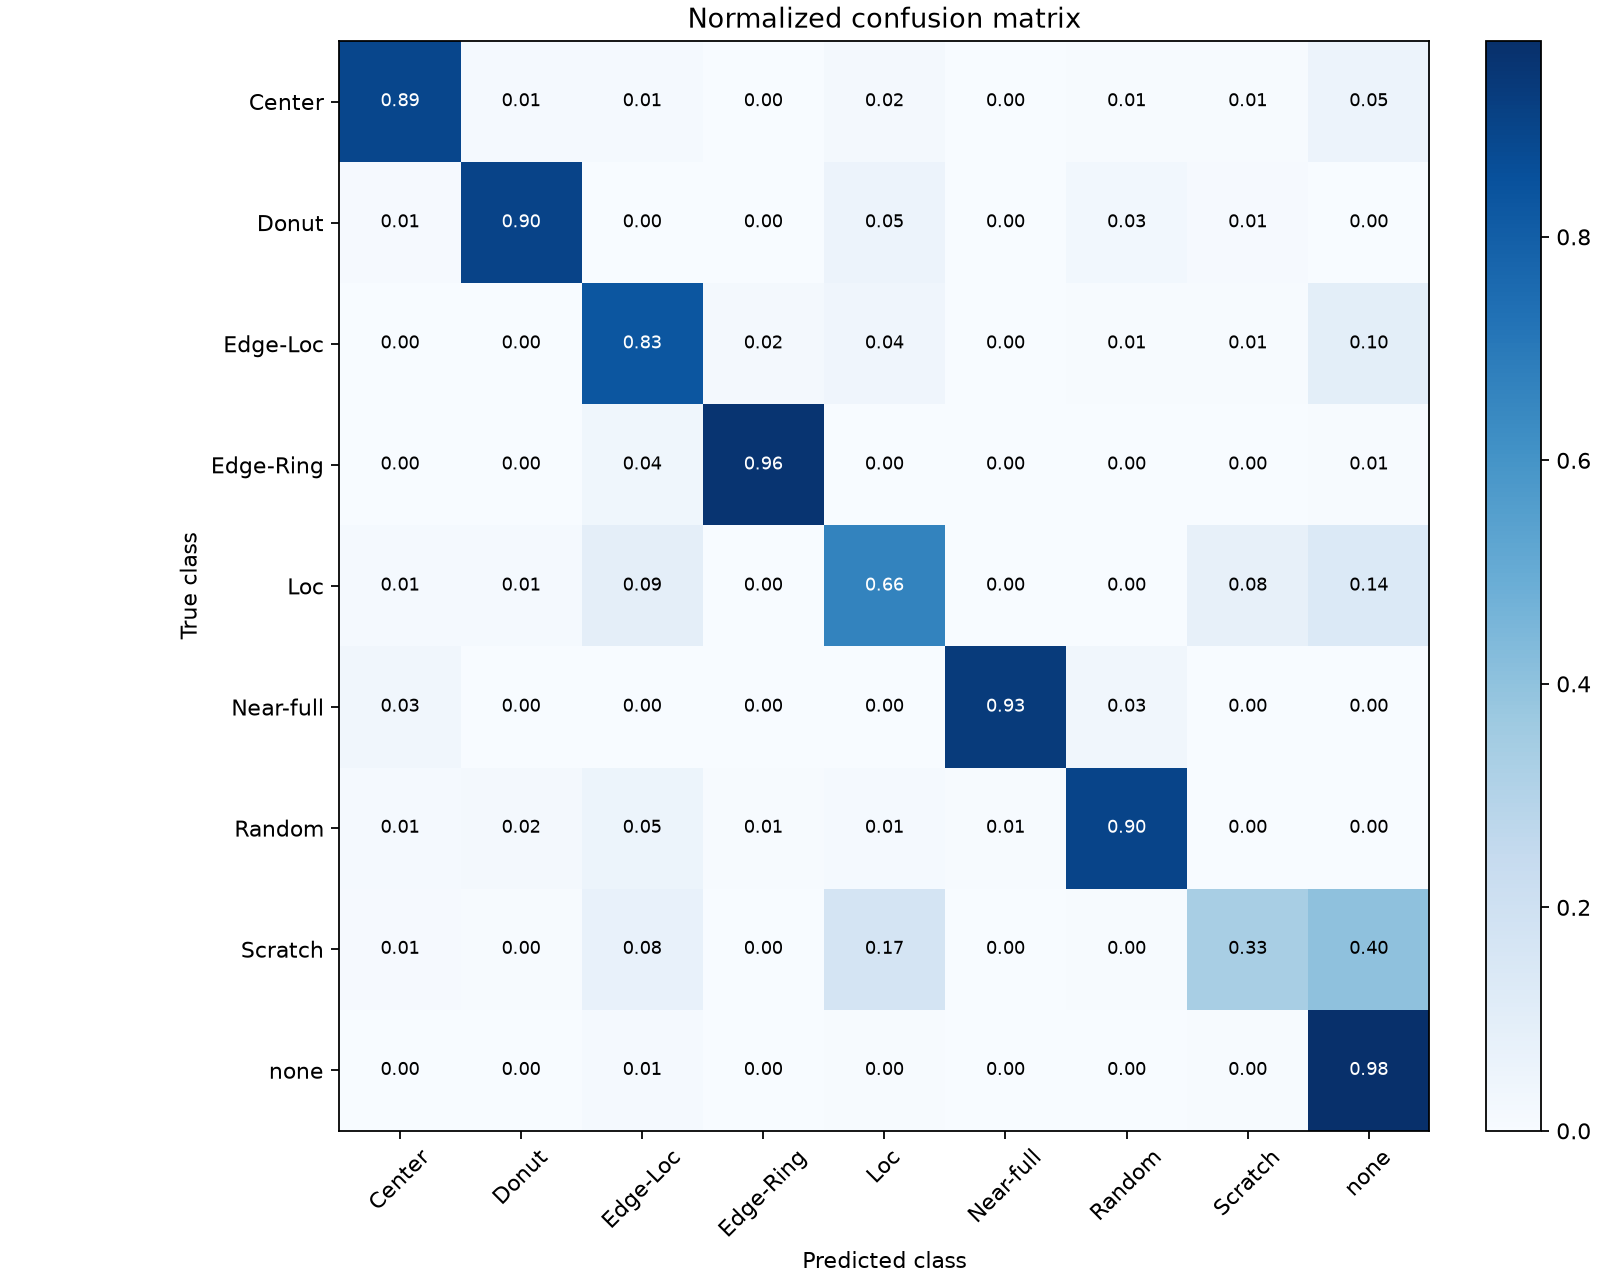

In [5]:
display(pd.DataFrame([selected_metrics["metrics"]]).round(4))
selected_per_class = pd.read_csv(
    OUTPUT_DIRECTORY / "selected_validation" / "per_class_metrics.csv"
)
display(selected_per_class.round(4))
display(
    Image(
        filename=OUTPUT_DIRECTORY
        / "selected_validation"
        / "confusion_matrix_normalized.png"
    )
)

## Decision

Use inverse-square-root weighted sampling as the shared default for model training. It raises mean validation macro-F1 from 0.7286 to 0.7955 while reducing run-to-run variation, with only a 0.0013 absolute decrease in accuracy. It materially improves minority-class recognition, including non-zero `Scratch` F1 where the unweighted baseline collapses. Validation and test loaders must retain their natural order and distribution. The result is specific to the controlled four-epoch baseline budget and must be recorded in later model configurations rather than assumed to be architecture-independent.